In [384]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys

import random
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [385]:
REGION = 'ExtNord'
YEAR = 2018

In [386]:
grouped_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_grouped.csv', encoding=enc)
grouped_file_previous = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR-1}_grouped.csv', encoding=enc)

In [387]:
grouped_file.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.151310,-0.166834,-0.314616,0.166834,0.152904,-0.162812,-0.312767,0.162812,0.013899,0.012870,0.015104,0.012870,26.42,36.49,16.34,14.82,42.41,0.0,0.0,0.0,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36,30,12,12,1,6,7,30.12,23.75,62.50,282.94,52.0,14.0,38.0,27.33,29.00,34.00,27.33,1863.0,531.0,0.0,130.19,1394.0,0.0,41.0,1394.0
1,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.158673,-0.165179,-0.291362,0.165179,0.159565,-0.159433,-0.291704,0.159433,0.011098,0.013526,0.013611,0.013526,27.08,36.91,17.25,13.84,43.71,0.0,0.0,0.0,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36,30,12,12,1,6,7,30.58,24.67,61.67,296.83,53.0,13.0,40.0,27.17,29.83,34.33,27.17,1711.0,498.0,0.0,134.18,1300.0,0.0,31.0,1300.0
2,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.148466,-0.160256,-0.315931,0.160256,0.157350,-0.152663,-0.323825,0.152663,0.013963,0.010952,0.012354,0.010952,26.05,35.97,16.12,14.66,42.32,0.0,0.0,0.0,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36,30,12,12,1,6,7,29.67,24.50,61.25,258.79,52.0,12.0,40.0,26.83,28.83,33.00,26.83,1850.0,524.0,0.0,129.56,1377.0,0.0,37.0,1377.0
3,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.153419,-0.163862,-0.324551,0.163862,0.152033,-0.165212,-0.324672,0.165212,0.009799,0.008791,0.011593,0.008791,26.09,35.29,16.88,15.00,41.13,0.0,0.0,0.0,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36,30,12,12,1,6,7,29.54,23.25,62.84,257.13,51.0,14.0,37.0,26.83,28.67,33.17,26.83,1921.0,572.0,0.0,131.18,1434.0,0.0,32.0,1434.0
4,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.159399,-0.149301,-0.310016,0.149301,0.156031,-0.153708,-0.301877,0.153708,0.013365,0.015316,0.013800,0.015316,26.84,36.96,16.72,15.22,43.72,0.0,0.0,0.0,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36,30,12,12,1,6,7,30.38,24.58,63.03,286.93,53.0,14.0,39.0,27.33,29.83,34.17,27.33,1825.0,523.0,0.0,130.76,1359.0,0.0,33.0,1359.0


In [388]:
grouped_file.shape

(3804, 75)

In [389]:
grouped_file_previous.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2017-01,2017,1,2016,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.188146,-0.136080,-0.344656,0.136080,0.190564,-0.132384,-0.341125,0.132384,0.016362,0.016033,0.014389,0.016033,27.90,35.92,19.84,15.94,42.01,0.0000,0.0000,0.0000,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36,30,12,12,1,6,7,31.21,24.92,67.34,331.98,52.0,15.0,37.0,28.50,31.33,35.67,27.50,1224.0,305.0,0.0,122.95,858.0,0.0,102.0,787.0
1,2017-01,2017,1,2016,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.181090,-0.157630,-0.341658,0.157630,0.180204,-0.153330,-0.337767,0.153330,0.013161,0.011406,0.010651,0.011406,28.42,37.21,19.58,16.00,43.27,0.0000,0.0014,0.0014,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36,30,12,12,1,6,7,31.12,24.92,67.34,366.26,52.0,15.0,37.0,27.50,31.83,35.83,26.83,1297.0,390.0,0.0,131.05,959.0,0.0,104.0,879.0
2,2017-01,2017,1,2016,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.183992,-0.128872,-0.345306,0.128872,0.186837,-0.124077,-0.348643,0.124077,0.014508,0.013145,0.009746,0.013145,27.31,35.15,19.44,15.29,41.66,0.0000,0.0000,0.0000,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36,30,12,12,1,6,7,30.75,24.83,63.68,318.02,52.0,13.0,39.0,27.83,30.17,34.67,27.83,1242.0,314.0,0.0,121.42,848.0,0.0,127.0,848.0
3,2017-01,2017,1,2016,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.200537,-0.125883,-0.334670,0.125883,0.199079,-0.128146,-0.337926,0.128146,0.012347,0.011983,0.012220,0.011983,27.24,34.71,19.74,15.79,41.14,0.0000,0.0000,0.0000,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36,30,12,12,1,6,7,30.67,24.00,68.57,285.51,50.0,15.0,35.0,28.17,30.50,34.00,27.67,1186.0,297.0,0.0,123.12,804.0,0.0,116.0,800.0
4,2017-01,2017,1,2016,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.185726,-0.130909,-0.347015,0.130909,0.185287,-0.132114,-0.346346,0.132114,0.017912,0.017043,0.013647,0.017043,27.96,36.34,19.54,15.56,42.69,0.0001,0.0025,0.0025,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36,30,12,12,1,6,7,31.17,24.83,67.12,321.46,52.0,15.0,37.0,27.83,31.17,35.33,27.83,1264.0,341.0,0.0,124.26,876.0,0.0,121.0,876.0


In [390]:
grouped_file_previous.shape

(3804, 75)

In [391]:
grouped_file['dt_placement'] = pd.to_datetime(grouped_file['dt_placement'], errors='coerce').dt.to_period('M')
grouped_file_previous['dt_placement'] = pd.to_datetime(grouped_file_previous['dt_placement'], errors='coerce').dt.to_period('M')

In [392]:
grouped_file

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.151310,-0.166834,-0.314616,0.166834,0.152904,-0.162812,-0.312767,0.162812,0.013899,0.012870,0.015104,0.012870,26.42,36.49,16.34,14.82,42.41,0.0000,0.0000,0.0000,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36,30,12,12,1,6,7,30.12,23.75,62.50,282.94,52.0,14.0,38.0,27.33,29.00,34.00,27.33,1863.0,531.0,0.0,130.19,1394.0,0.0,41.0,1394.0
1,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.158673,-0.165179,-0.291362,0.165179,0.159565,-0.159433,-0.291704,0.159433,0.011098,0.013526,0.013611,0.013526,27.08,36.91,17.25,13.84,43.71,0.0000,0.0000,0.0000,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36,30,12,12,1,6,7,30.58,24.67,61.67,296.83,53.0,13.0,40.0,27.17,29.83,34.33,27.17,1711.0,498.0,0.0,134.18,1300.0,0.0,31.0,1300.0
2,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.148466,-0.160256,-0.315931,0.160256,0.157350,-0.152663,-0.323825,0.152663,0.013963,0.010952,0.012354,0.010952,26.05,35.97,16.12,14.66,42.32,0.0000,0.0000,0.0000,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36,30,12,12,1,6,7,29.67,24.50,61.25,258.79,52.0,12.0,40.0,26.83,28.83,33.00,26.83,1850.0,524.0,0.0,129.56,1377.0,0.0,37.0,1377.0
3,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.153419,-0.163862,-0.324551,0.163862,0.152033,-0.165212,-0.324672,0.165212,0.009799,0.008791,0.011593,0.008791,26.09,35.29,16.88,15.00,41.13,0.0000,0.0000,0.0000,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36,30,12,12,1,6,7,29.54,23.25,62.84,257.13,51.0,14.0,37.0,26.83,28.67,33.17,26.83,1921.0,572.0,0.0,131.18,1434.0,0.0,32.0,1434.0
4,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.159399,-0.149301,-0.310016,0.149301,0.156031,-0.153708,-0.301877,0.153708,0.013365,0.015316,0.013800,0.015316,26.84,36.96,16.72,15.22,43.72,0.0000,0.0000,0.0000,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36,30,12,12,1,6,7,30.38,24.58,63.03,286.93,53.0,14.0,39.0,27.33,29.83,34.17,27.33,1825.0,523.0,0.0,130.76,1359.0,0.0,33.0,1359.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3799,2018-12,2018,12,2017,0.0,1.000,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,0.229750,-0.156644,-0.356824,0.156644,0.231528,-0.151138,-0.356241,0.151138,0.008295,0.008090,0.007489,0.008090,25.29,33.24,17.25,15.57,39.37,0.0194,0.6000,0.6000,108691.34,1322.49,4.33,172.99,759.46,179.21,0.0,62.92,2224.04,1215.46,3.21,70.29,46.80,2.81,0.0,93.52,31,36,30,12,12,3,5,8,27.46,22.58,62.73,250.87,48.0,12.0,36.0,25.00,27.50,30.50,25.00,2061.0,593.0,0.0,127.73,1523.0,0.0,53.0,1523.0
3800,2018-12,2018,12,2017,0.0,1.000,extreme nord,mayo-tsanaga,roua,n

In [393]:
weather_acc = grouped_file[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc']].copy()
weather_acc_previous = grouped_file_previous[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc']].copy()

weather_df = pd.concat([weather_acc_previous, weather_acc], ignore_index=True)
weather_df.rename(columns={'dt_placement': 'dt_weather_acc'}, inplace=True)

In [394]:
weather_df

,dt_weather_acc,GID0,GID1,GID2,GID3,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2017-01,extreme nord,diamare,bogo,balaza,15.94,42.01,0.0000
1,2017-01,extreme nord,diamare,bogo,balda,16.00,43.27,0.0014
2,2017-01,extreme nord,diamare,bogo,bogo,15.29,41.66,0.0000
3,2017-01,extreme nord,diamare,bogo,borai,15.79,41.14,0.0000
4,2017-01,extreme nord,diamare,bogo,guinggley,15.56,42.69,0.0025
...,...,...,...,...,...,...,...,...
7603,2018-12,extreme nord,mayo-tsanaga,roua,midre,15.57,39.37,0.6000
7604,2018-12,extreme nord,mayo-tsanaga,roua,ndimche,15.79,39.32,1.3137
7605,2018-12,extreme nord,mayo-tsanaga,roua,roua,16.33,38.91,0.4100
7606,2018-12,extreme nord,mayo-tsanaga,roua,soulede,15.61,40.11,0.5580


In [395]:
biovars_temp = grouped_file_previous[['year', 'GID0', 'GID1', 'GID2', 'GID3'] + [col for col in grouped_file_previous.columns if 'bio' in col] ].copy()
biovars_temp.rename(columns={'year': 'year_biovars'}, inplace=True)

In [396]:
biovars_df = (
    biovars_temp
    .groupby(['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'])
    .mean(numeric_only=True)
    .reset_index()
    .round(2)
)

In [397]:
biovars_df.head()

,year_biovars,GID0,GID1,GID2,GID3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2017,extreme nord,diamare,bogo,balaza,31.21,24.92,67.34,331.98,52.0,15.0,37.0,28.50,31.33,35.67,27.50,1224.0,305.0,0.0,122.95,858.0,0.0,102.0,787.0
1,2017,extreme nord,diamare,bogo,balda,31.12,24.92,67.34,366.26,52.0,15.0,37.0,27.50,31.83,35.83,26.83,1297.0,390.0,0.0,131.05,959.0,0.0,104.0,879.0
2,2017,extreme nord,diamare,bogo,bogo,30.75,24.83,63.68,318.02,52.0,13.0,39.0,27.83,30.17,34.67,27.83,1242.0,314.0,0.0,121.42,848.0,0.0,127.0,848.0
3,2017,extreme nord,diamare,bogo,borai,30.67,24.00,68.57,285.51,50.0,15.0,35.0,28.17,30.50,34.00,27.67,1186.0,297.0,0.0,123.12,804.0,0.0,116.0,800.0
4,2017,extreme nord,diamare,bogo,guinggley,31.17,24.83,67.12,321.46,52.0,15.0,37.0,27.83,31.17,35.33,27.83,1264.0,341.0,0.0,124.26,876.0,0.0,121.0,876.0


In [398]:
biovars_df.shape

(317, 24)

In [399]:
df_current = grouped_file.drop(columns=[col for col in grouped_file.columns if 'bio' in col] + ['monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc', 'rainfall_acc']).copy()

In [400]:
df_current.shape

(3804, 52)

In [401]:
df_current['year_biovars'] = df_current['year']-1
df_current['dt_weather_acc'] = df_current['dt_placement']-1

In [402]:
df_current.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc
0,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.151310,-0.166834,-0.314616,0.166834,0.152904,-0.162812,-0.312767,0.162812,0.013899,0.012870,0.015104,0.012870,26.42,36.49,16.34,0.0,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36,30,12,12,1,6,7,2017,2017-12
1,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.158673,-0.165179,-0.291362,0.165179,0.159565,-0.159433,-0.291704,0.159433,0.011098,0.013526,0.013611,0.013526,27.08,36.91,17.25,0.0,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36,30,12,12,1,6,7,2017,2017-12
2,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.148466,-0.160256,-0.315931,0.160256,0.157350,-0.152663,-0.323825,0.152663,0.013963,0.010952,0.012354,0.010952,26.05,35.97,16.12,0.0,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36,30,12,12,1,6,7,2017,2017-12
3,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.153419,-0.163862,-0.324551,0.163862,0.152033,-0.165212,-0.324672,0.165212,0.009799,0.008791,0.011593,0.008791,26.09,35.29,16.88,0.0,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36,30,12,12,1,6,7,2017,2017-12
4,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.159399,-0.149301,-0.310016,0.149301,0.156031,-0.153708,-0.301877,0.153708,0.013365,0.015316,0.013800,0.015316,26.84,36.96,16.72,0.0,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36,30,12,12,1,6,7,2017,2017-12


In [403]:
df_current.shape

(3804, 54)

In [404]:
dataset = pd.merge(df_current, biovars_df, on=['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [405]:
dataset.shape

(3804, 73)

In [406]:
dataset = pd.merge(dataset, weather_df, on=['dt_weather_acc', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [407]:
dataset.shape

(3804, 76)

In [408]:
dataset.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.151310,-0.166834,-0.314616,0.166834,0.152904,-0.162812,-0.312767,0.162812,0.013899,0.012870,0.015104,0.012870,26.42,36.49,16.34,0.0,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36,30,12,12,1,6,7,2017,2017-12,31.21,24.92,67.34,331.98,52.0,15.0,37.0,28.50,31.33,35.67,27.50,1224.0,305.0,0.0,122.95,858.0,0.0,102.0,787.0,16.01,43.36,0.0620
1,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.158673,-0.165179,-0.291362,0.165179,0.159565,-0.159433,-0.291704,0.159433,0.011098,0.013526,0.013611,0.013526,27.08,36.91,17.25,0.0,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36,30,12,12,1,6,7,2017,2017-12,31.12,24.92,67.34,366.26,52.0,15.0,37.0,27.50,31.83,35.83,26.83,1297.0,390.0,0.0,131.05,959.0,0.0,104.0,879.0,15.94,44.63,0.0681
2,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.148466,-0.160256,-0.315931,0.160256,0.157350,-0.152663,-0.323825,0.152663,0.013963,0.010952,0.012354,0.010952,26.05,35.97,16.12,0.0,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36,30,12,12,1,6,7,2017,2017-12,30.75,24.83,63.68,318.02,52.0,13.0,39.0,27.83,30.17,34.67,27.83,1242.0,314.0,0.0,121.42,848.0,0.0,127.0,848.0,16.56,43.42,0.0425
3,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.153419,-0.163862,-0.324551,0.163862,0.152033,-0.165212,-0.324672,0.165212,0.009799,0.008791,0.011593,0.008791,26.09,35.29,16.88,0.0,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36,30,12,12,1,6,7,2017,2017-12,30.67,24.00,68.57,285.51,50.0,15.0,35.0,28.17,30.50,34.00,27.67,1186.0,297.0,0.0,123.12,804.0,0.0,116.0,800.0,16.98,43.26,0.0517
4,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.159399,-0.149301,-0.310016,0.149301,0.156031,-0.153708,-0.301877,0.153708,0.013365,0.015316,0.013800,0.015316,26.84,36.96,16.72,0.0,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36,30,12,12,1,6,7,2017,2017-12,31.17,24.83,67.12,321.46,52.0,15.0,37.0,27.83,31.17,35.33,27.83,1264.0,341.0,0.0,124.26,876.0,0.0,121.0,876.0,16.48,44.54,0.0575


In [409]:
dataset.rename(columns={'monthly_lst_min': 'lst_min_prev_month', 'monthly_lst_max': 'lst_max_prev_month', 'monthly_rainfall_acc': 'rainfall_acc_prev_month'}, inplace=True)

<Axes: >

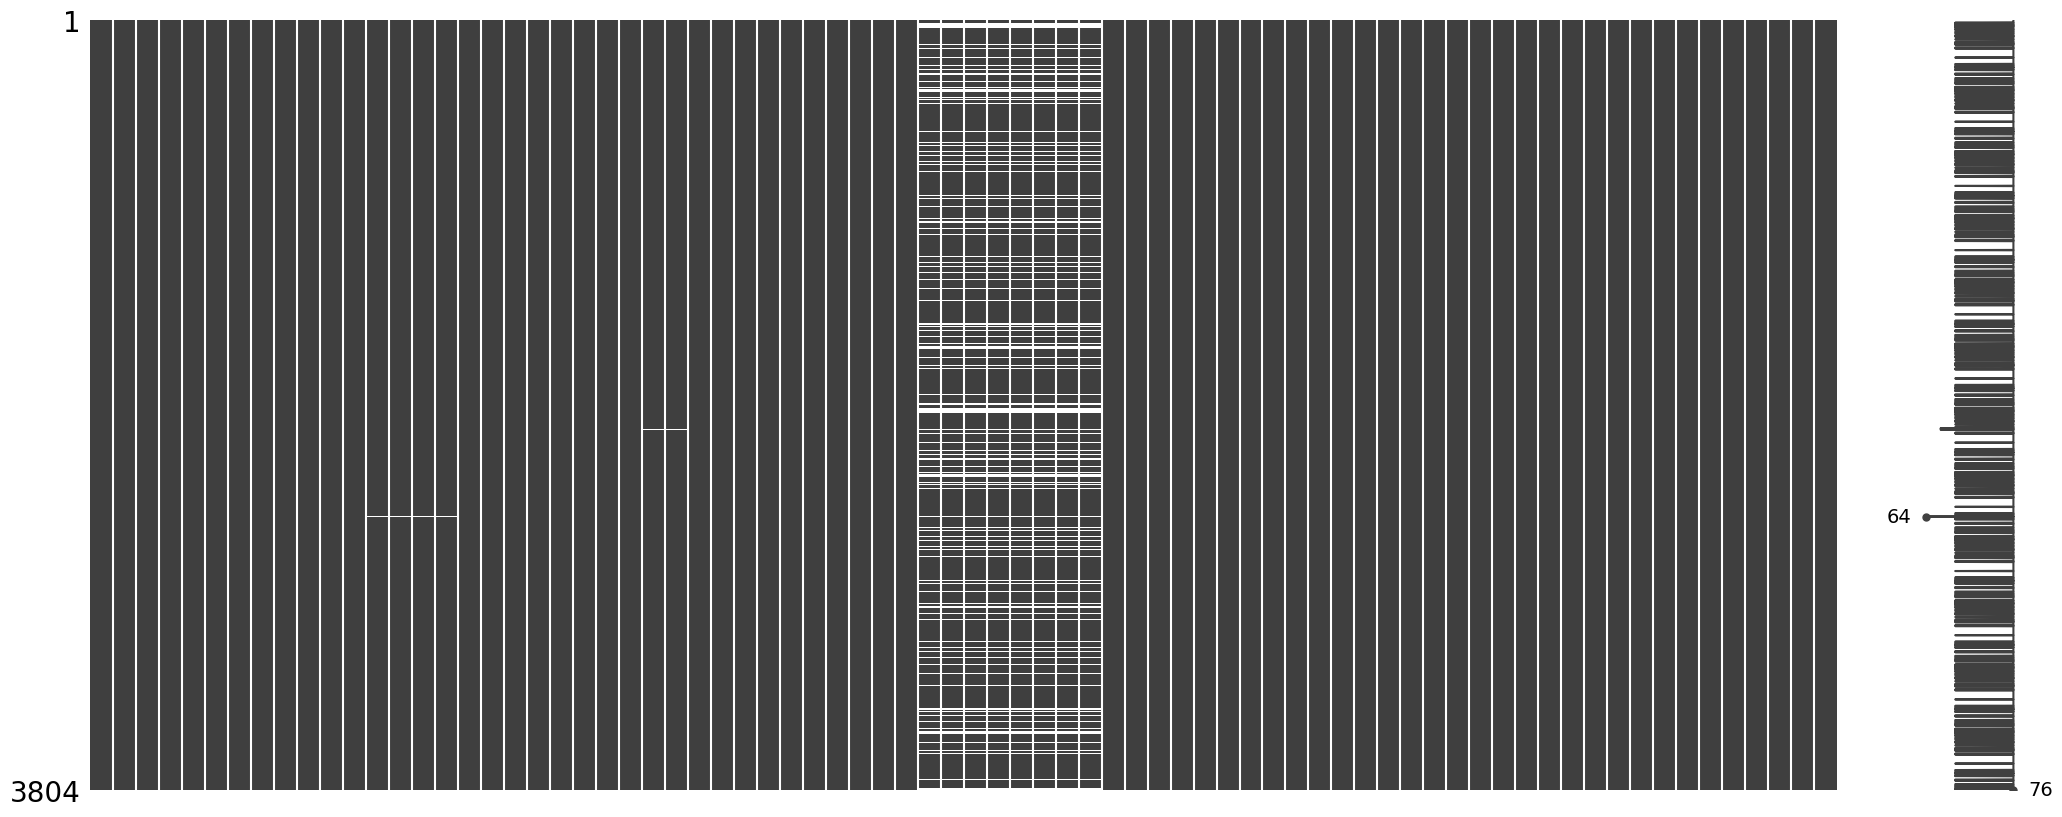

In [410]:
msno.matrix(dataset)

In [411]:
dataset

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst_min_prev_month,lst_max_prev_month,rainfall_acc_prev_month
0,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.151310,-0.166834,-0.314616,0.166834,0.152904,-0.162812,-0.312767,0.162812,0.013899,0.012870,0.015104,0.012870,26.42,36.49,16.34,0.0000,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36,30,12,12,1,6,7,2017,2017-12,31.21,24.92,67.34,331.98,52.0,15.0,37.0,28.50,31.33,35.67,27.50,1224.0,305.0,0.0,122.95,858.0,0.0,102.0,787.0,16.01,43.36,0.0620
1,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.158673,-0.165179,-0.291362,0.165179,0.159565,-0.159433,-0.291704,0.159433,0.011098,0.013526,0.013611,0.013526,27.08,36.91,17.25,0.0000,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36,30,12,12,1,6,7,2017,2017-12,31.12,24.92,67.34,366.26,52.0,15.0,37.0,27.50,31.83,35.83,26.83,1297.0,390.0,0.0,131.05,959.0,0.0,104.0,879.0,15.94,44.63,0.0681
2,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.148466,-0.160256,-0.315931,0.160256,0.157350,-0.152663,-0.323825,0.152663,0.013963,0.010952,0.012354,0.010952,26.05,35.97,16.12,0.0000,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36,30,12,12,1,6,7,2017,2017-12,30.75,24.83,63.68,318.02,52.0,13.0,39.0,27.83,30.17,34.67,27.83,1242.0,314.0,0.0,121.42,848.0,0.0,127.0,848.0,16.56,43.42,0.0425
3,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.153419,-0.163862,-0.324551,0.163862,0.152033,-0.165212,-0.324672,0.165212,0.009799,0.008791,0.011593,0.008791,26.09,35.29,16.88,0.0000,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36,30,12,12,1,6,7,2017,2017-12,30.67,24.00,68.57,285.51,50.0,15.0,35.0,28.17,30.50,34.00,27.67,1186.0,297.0,0.0,123.12,804.0,0.0,116.0,800.0,16.98,43.26,0.0517
4,2018-01,2018,1,2017,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.159399,-0.149301,-0.310016,0.149301,0.156031,-0.153708,-0.301877,0.153708,0.013365,0.015316,0.013800,0.015316,26.84,36.96,16.72,0.0000,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36,30,12,12,1,6,7,2017,2017-12,31.17,24.83,67.12,321.46,52.0,15.0,37.0,27.83,31.17,35.33,27.83,1264.0,341.0,0.0,124.26,876.0,0.0,121.0,876.0,16.48,44.54,0.0575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3799,2018-12,2018,12,2017,0.0,1.000,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,0.229750,-0.156644,-0.356824,0.156644,0.231528,-0.151138,-0.356241,0.151138,0.008295,0.008090,0.007489,0.008090,25.29,33.24,17.25,0.0194,108691.34,1322.49,4.33,172.99,759.46,179.21,0.0,62.92,2224.04,1215.46,3.21,70.29,46.80,2.81,0.0,93.52,31,36,30,12,12,3,5,8,2017,2018-11,28.88,23.42,68.87,241.33,48.0,14.0,34.0,27.17,27.83,32.00,26.33,1613.0,401.0,0.0,118.91,1123.0,4.0,188.0,1010.0,18.92,41.07,1.6420
3800,201

In [412]:
dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_X_{YEAR}.csv', encoding=enc)